# **Netflix Movies & TV Shows - Exploratory Data Analysis (EDA)**

## **Project Overview**

This project performs Exploratory Data Analysis (EDA) on the Netflix Movies and TV Shows dataset. The goal of this analysis is to uncover patterns, trends, and insights related to Netflix content using statistical summaries and visualizations.

The analysis focuses on:
- Content distribution between Movies and TV Shows
- Country-wise content production
- Release year trends
- Ratings and genre analysis
- Missing value analysis
- Content growth patterns

## **Objectives**

- Understand the structure of the dataset
- Analyze content trends and distributions
- Identify important patterns and relationships
- Visualize data using charts and graphs
- Generate meaningful business insights

## **Technologies Used**

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

## *Importing Required Libraries*

In this step, the necessary Python libraries are imported for data manipulation, analysis, and visualization. These libraries help in handling datasets, performing statistical analysis, and creating graphical representations of the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## *Loading the Dataset*

The Netflix Movies and TV Shows dataset is loaded into a Pandas DataFrame for analysis. The dataset contains information about Netflix content such as title, type, release year, rating, country, and genre.

In [2]:
dataset = pd.read_csv('netflix_titles.csv')

In [3]:
dataset.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## *Exploring the Dataset*

In this step, the structure and properties of the dataset are explored. This includes checking the number of rows and columns, understanding data types, and identifying missing values present in the dataset.

In [4]:
dataset.shape

(8807, 12)

In [5]:
dataset.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
dataset.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


## *Data Cleaning*

Data cleaning is performed to improve the quality of the dataset before analysis. This includes checking for duplicate records and identifying missing values in important columns.

In [8]:
dataset.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


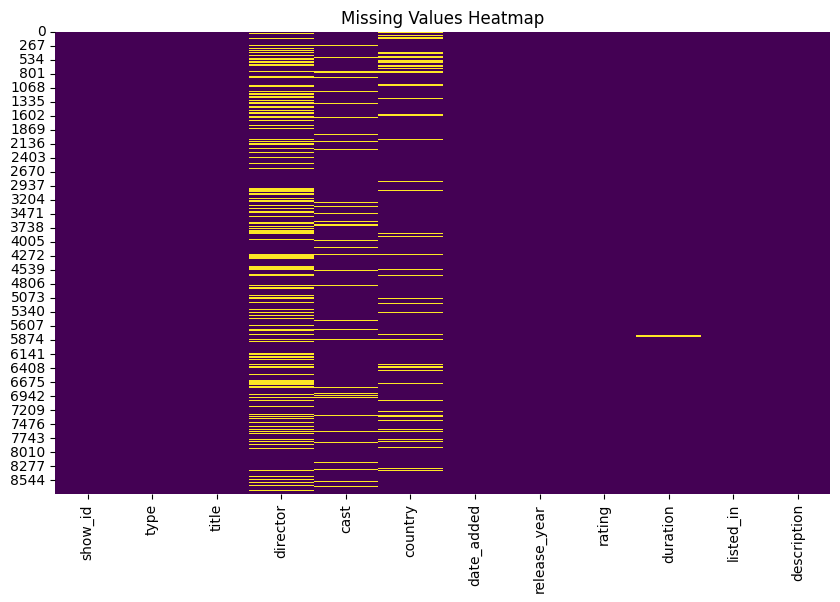

In [9]:
plt.figure(figsize=(10,6))

sns.heatmap(dataset.isnull(), cbar=False, cmap='viridis')

plt.title("Missing Values Heatmap")

plt.show()

In [10]:
dataset.duplicated().sum()

np.int64(0)

In [11]:
dataset = dataset.drop_duplicates()

In [12]:
dataset.shape

(8807, 12)

## *Missing Value Analysis*

This section analyzes missing values present in the dataset. Missing data can affect the quality of analysis and visualizations. Understanding missing values helps identify incomplete records and data quality issues.

In [13]:
missing_values = dataset.isnull().sum()

missing_values

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [14]:
missing_percentage = (dataset.isnull().sum() / len(dataset)) * 100

missing_percentage.sort_values(ascending=False)

,0
director,29.908028
country,9.435676
cast,9.367549
date_added,0.113546
rating,0.045418
duration,0.034064
show_id,0.000000
type,0.000000
title,0.000000
release_year,0.000000


### *Missing Values Percentage Visualization*

The following visualization represents the percentage of missing values present in different columns of the dataset.

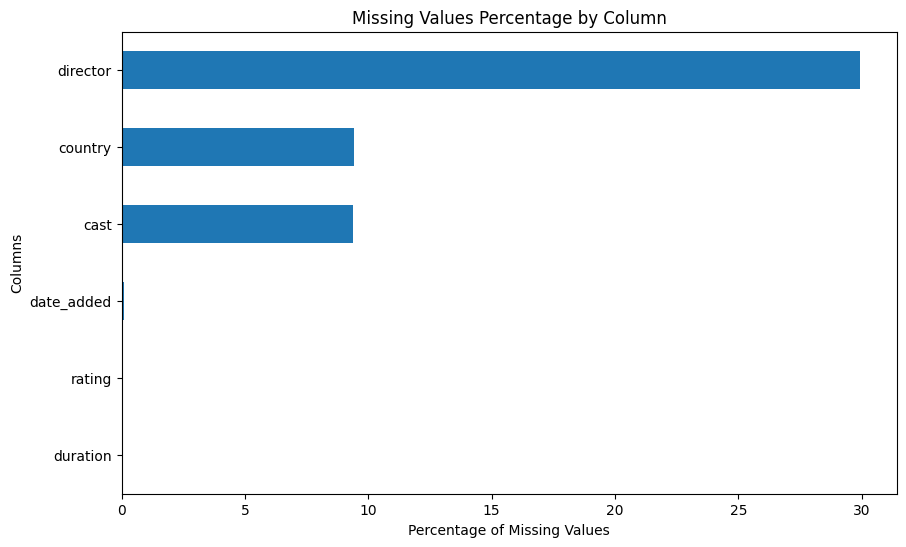

In [15]:
missing_percentage = missing_percentage[missing_percentage > 0]

plt.figure(figsize=(10,6))

missing_percentage.sort_values().plot(kind='barh')

plt.xlabel("Percentage of Missing Values")
plt.ylabel("Columns")

plt.title("Missing Values Percentage by Column")

plt.show()

### *Observation*

The dataset contains missing values primarily in the `director`, `cast`, and `country` columns. The `director` column has the highest percentage of missing values. These missing values are common in real-world datasets and can impact analysis if not properly handled.

## *Statistical Analysis*

Statistical analysis helps summarize and understand the important characteristics of the dataset. This section explores the distribution of Netflix content based on content type, ratings, release years, and other categorical features.

In [16]:
dataset.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


### *Movies vs TV Shows Distribution*

This analysis compares the number of Movies and TV Shows available in the Netflix dataset.

In [17]:
dataset['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


### *Most Common Content Ratings*

This analysis identifies the most frequently occurring Netflix content ratings in the dataset.

In [18]:
dataset['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


### *Release Year Analysis*

This analysis explores the distribution of Netflix content based on release years.

In [19]:
dataset['release_year'].describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


### *Top Content Producing Countries*

This analysis identifies countries contributing the highest amount of Netflix content.

In [20]:
dataset['country'].value_counts().head(10)

,count
country,
United States,2818
India,972
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124
Mexico,110


## *Content Type Distribution*

This visualization compares the number of Movies and TV Shows available on Netflix. It helps understand the dominant type of content present in the dataset.

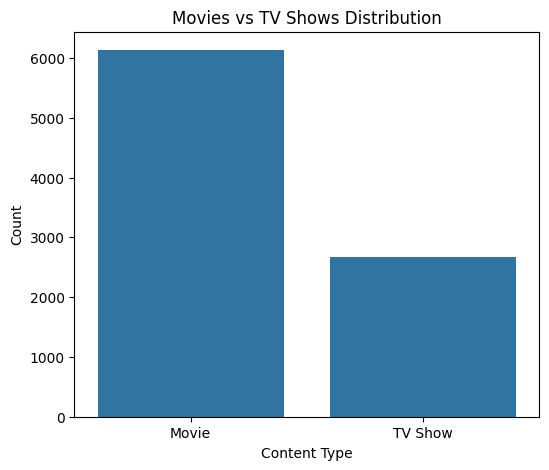

In [21]:
plt.figure(figsize=(6,5))

sns.countplot(x='type', data=dataset)

plt.title("Movies vs TV Shows Distribution")

plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

## *Top 10 Content Producing Countries*

This visualization highlights the countries contributing the highest amount of content to Netflix.

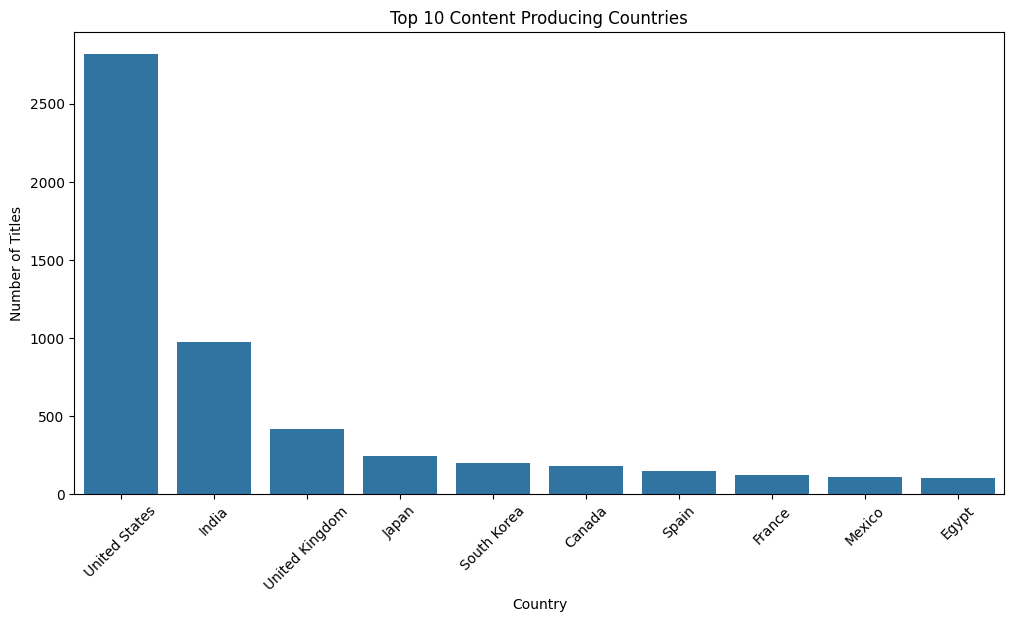

In [22]:
top_countries = dataset['country'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)

plt.title("Top 10 Content Producing Countries")

plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

## *Content Release Trend Over the Years*

This visualization shows how Netflix content releases have changed over time.

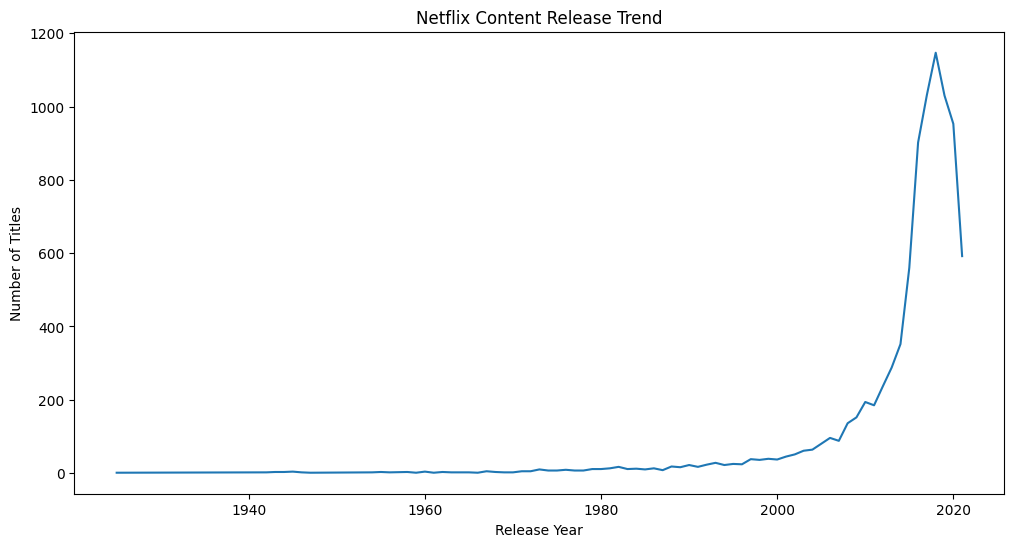

In [23]:
plt.figure(figsize=(12,6))

dataset['release_year'].value_counts()\
.sort_index().plot()

plt.title("Netflix Content Release Trend")

plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

## *Most Common Netflix Ratings*

This visualization displays the most frequently occurring content ratings available on Netflix.

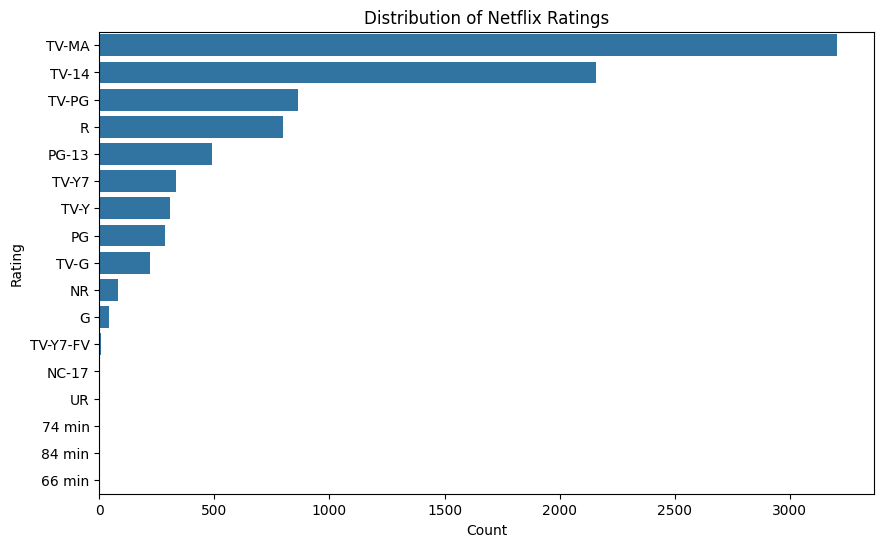

In [24]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='rating',
    data=dataset,
    order=dataset['rating'].value_counts().index
)

plt.title("Distribution of Netflix Ratings")

plt.xlabel("Count")
plt.ylabel("Rating")

plt.show()

# **Insights & Findings**

## *Key Insights*

1. Movies dominate Netflix content compared to TV Shows, indicating that Netflix primarily focuses on movie distribution.

2. The United States contributes the highest amount of Netflix content, followed by countries such as India and the United Kingdom.

3. Netflix content releases increased significantly after the year 2000, with rapid growth observed after 2015.

4. The most common content rating on Netflix is `TV-MA`, showing that a large portion of content targets mature audiences.

5. Certain columns such as `director`, `cast`, and `country` contain missing values, which is common in real-world datasets.

6. Netflix contains content spanning many decades, with release years ranging from 1925 to 2021.

7. The dataset demonstrates strong diversity in genres, countries, and content types available on the platform.

## **Conclusion**

This Exploratory Data Analysis (EDA) project analyzed the Netflix Movies and TV Shows dataset to uncover patterns, trends, and insights related to Netflix content. The analysis revealed that Movies dominate the platform, the United States produces the highest amount of content, and Netflix content releases have grown rapidly in recent years.

Various statistical summaries and visualizations were used to better understand content distribution, ratings, release trends, and missing values present in the dataset. The project demonstrates the importance of data exploration and visualization in understanding real-world datasets and generating meaningful business insights.